# CLIP

https://huggingface.co/docs/transformers/en/model_doc/clip

CLIP(Contrastive Language-Image Pre-training)을 사용하여 이미지와 텍스트를 같은 의미 공간에서 비교하는 방법을 확인한다.

1. 이미지를 벡터로 변환하는 Vision Encoder가 있다.
2. 텍스트를 벡터로 변환하는 Text Encoder가 있다.
3. 이미지 벡터와 텍스트 벡터를 같은 임베딩 공간에 배치한다.
4. 서로 의미가 가까운 이미지와 텍스트는 벡터도 가깝게, 관련 없는 이미지와 텍스트는 벡터도 멀게 학습한다.

이러한 방식 덕분에 CLIP은 별도의 분류기 학습 없이도 텍스트 후보를 바꿔가며 zero-shot image classification을 수행할 수 있다.

중요한 점은 CLIP이 텍스트를 생성하는 모델은 아니라는 것이다. CLIP은 이미지를 보고 설명 문장을 새로 만들어내는 모델이 아니라, 이미지와 텍스트 후보가 얼마나 잘 맞는지 점수화하는 모델이다.

In [1]:
import torch
from PIL import Image
from pathlib import Path
from urllib.request import urlretrieve
import matplotlib.pyplot as plt

from transformers import CLIPProcessor, CLIPModel, pipeline

## 예제 이미지 준비

이미지 예제는 COCO validation 이미지 중 하나를 사용한다.

이미지 크기: (640, 480)
이미지 타입: <class 'PIL.Image.Image'>


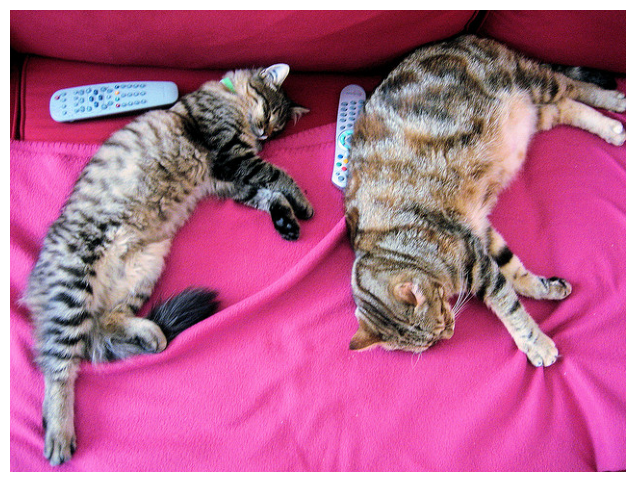

In [2]:
image_dir = Path('images')
image_dir.mkdir(exist_ok=True)

image_path = image_dir / 'coco_cats.jpg'
image_url = 'http://images.cocodataset.org/val2017/000000039769.jpg'

if not image_path.exists():
    urlretrieve(image_url, image_path)

# Image.open()은 이미지 파일을 PIL 이미지 객체로 불러온다.
# convert('RGB')는 이미지를 RGB 3채널 형식으로 맞춘다.
image = Image.open(image_path).convert('RGB')

print('이미지 크기:', image.size)
print('이미지 타입:', type(image))

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.show()

## CLIP 모델과 Processor 로드

https://huggingface.co/openai/clip-vit-base-patch32

`openai/clip-vit-base-patch32` 모델 사용

In [3]:
model_id = 'openai/clip-vit-base-patch32'

processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)
model.eval()

print('모델 로드 완료 : ', model_id)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

c:\Users\Playdata\AppData\Local\miniforge3\envs\dl_nlp_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Playdata\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


모델 로드 완료 :  openai/clip-vit-base-patch32


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

## 텍스트 후보 준비

In [4]:
# 이미지와 관련 있을만한 후보와 관련 없을만한 후보를 모두 준비한다.
texts = [
    'a photo of a cat',
    'a photo of a dog',
    'a photo of a sofa',
    'a photo of a remote control',
    'a photo of a bus'
]

## Processor로 이미지와 텍스트를 모델 입력으로 변환

In [5]:
inputs = processor(
    text=texts,
    images=image,
    padding=True,
    return_tensors='pt'
)

for key, value in inputs.items():
    print(key, value.shape)

pixel_values torch.Size([1, 3, 224, 224])
input_ids torch.Size([5, 8])
attention_mask torch.Size([5, 8])


## CLIP으로 이미지-텍스트 유사도 계산

In [6]:
with torch.no_grad():
    outputs = model(**inputs)

logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=-1)

print('logits_per_image.shape : ', logits_per_image.shape)
print('probs.shape : ', probs.shape)

logits_per_image.shape :  torch.Size([1, 5])
probs.shape :  torch.Size([1, 5])


In [7]:
for text, score in zip(texts, probs[0]):
    print(f'{text} : {score.item():.4f}')

a photo of a cat : 0.5241
a photo of a dog : 0.0027
a photo of a sofa : 0.1240
a photo of a remote control : 0.3485
a photo of a bus : 0.0007


## 임베딩을 직접 꺼내 유사도 계산하기

In [8]:
with torch.no_grad():
    outputs = model(**inputs)

image_embeds = outputs.image_embeds
text_embeds = outputs.text_embeds 

print('image_embeds.shape : ', image_embeds.shape)
print('text_embeds.shape : ', text_embeds.shape)

image_embeds.shape :  torch.Size([1, 512])
text_embeds.shape :  torch.Size([5, 512])


In [ ]:
# L2 정규화 (정규화 후에는 벡터의 크기보다 방향이 중요해진다)
image_embeds_norm = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
text_embeds_norm = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

# 이미지 벡터와 텍스트 벡터의 유사도 계산
similarity = image_embeds_norm @ text_embeds_norm.T
similarity_probs = similarity.softmax(dim=-1)

print('similarity shape : ', similarity.shape)

# 코사인 유사도
for text, score in zip(texts, similarity_probs[0]):
    print(f'{text} : {score.item():.4f}')

similarity shape :  torch.Size([1, 5])
a photo of a cat : 0.2055
a photo of a dog : 0.1950
a photo of a sofa : 0.2026
a photo of a remote control : 0.2047
a photo of a bus : 0.1923


## 모델과 직접 계산한 유사도 차이
CLIP 모델은 내부적으로 이미지-텍스트 유사도에 학습 된 `logit_scale` 값을 곱해 출력한다. 

In [ ]:
# 학습 된 scale 값
print('CLIP logit_scale : ', model.logit_scale.exp().item())

CLIP logit_scale :  100.00000762939453


## 구체적인 설명 후보와 비교

In [13]:
descriptions = [
    'two cats sitting on a couch',
    'a dog running on the grass',
    'a bus driving on the road',
    'a plate of food on a table',
    'a person skiing in the snow'
]

inputs_desc = processor(
    text=descriptions,
    images=image,
    padding=True,
    return_tensors='pt'
)

with torch.no_grad():
    outputs_desc = model(**inputs_desc)
    desc_probs = outputs_desc.logits_per_image.softmax(dim=-1)    

for text, score in zip(descriptions, desc_probs[0]):
    print(f'{text} : {score.item():.4f}')

two cats sitting on a couch : 0.9997
a dog running on the grass : 0.0000
a bus driving on the road : 0.0000
a plate of food on a table : 0.0003
a person skiing in the snow : 0.0000


## pipeline 활용

In [14]:
clip_classifier = pipeline(
    task='zero-shot-image-classification',
    model=model_id
)

candidate_labels = ['cat', 'dog', 'sofa', 'remote control', 'bus']

pipeline_results = clip_classifier(image, candidate_labels=candidate_labels)

for item in pipeline_results:
    print(f'{item['label']} : {item['score']:.4f}')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


sofa : 0.5470
cat : 0.3077
remote control : 0.1388
bus : 0.0044
dog : 0.0021
